# Linear Regression

## Learning objective

This notebook covers **ordinary least squares (OLS)** linear regression and
its closed-form solution, the *normal equation*. You should finish able to:

- state the OLS objective and the normal-equation solution,
- implement linear regression from scratch with an intercept term,
- evaluate it with a train/test split using MSE and $R^2$, and
- discuss the assumptions and limitations of the model.

## The mathematical idea

With a feature matrix $X \in \mathbb{R}^{n \times d}$ and targets
$\mathbf{y}$, linear regression predicts $\hat{\mathbf{y}} = X\boldsymbol\beta$.
To include an **intercept** we prepend a column of ones to $X$, so the first
entry of $\boldsymbol\beta$ is the intercept.

OLS chooses $\boldsymbol\beta$ to minimize the sum of squared residuals,

$$
\min_{\boldsymbol\beta}\; \lVert X\boldsymbol\beta - \mathbf{y} \rVert_2^2 .
$$

Setting the gradient to zero gives the **normal equation**, whose solution is

$$
\boldsymbol\beta = (X^\top X)^{-1} X^\top \mathbf{y} .
$$

Rather than inverting $X^\top X$ explicitly (which can be numerically
fragile), we solve the linear system directly.

We report two metrics: the **mean squared error** and the coefficient of
determination

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2},
$$

where $\bar{y}$ is the mean target. $R^2 = 1$ is a perfect fit, while $R^2 = 0$
is no better than predicting the mean.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

## A reproducible synthetic dataset

We generate data from a known linear relationship with two features plus noise,
so we can later compare the recovered coefficients against the true ones.

In [2]:
n_samples = 200
true_intercept = 5.0
true_coefs = np.array([2.0, -1.5])

X = rng.uniform(-3, 3, size=(n_samples, 2))
noise = rng.normal(0, 1.0, size=n_samples)
y = true_intercept + X @ true_coefs + noise

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (200, 2)
Target shape: (200,)


## A train/test split

We shuffle the rows with a fixed seed and hold out 25% of the data for testing,
so the reported test metrics reflect performance on unseen points.

In [3]:
n_test = n_samples // 4
perm = rng.permutation(n_samples)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 150
Test size: 50


## Linear regression from scratch

The class adds an intercept column, solves the normal equation with
`np.linalg.lstsq` (a numerically stable least-squares solver), and exposes the
learned intercept and coefficients separately.

In [4]:
class LinearRegressionScratch:
    """Ordinary least squares via the normal equation, with an intercept."""

    def _add_intercept(self, X):
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        X_aug = self._add_intercept(X)
        # Solve X_aug @ beta = y in the least-squares sense.
        beta, *_ = np.linalg.lstsq(X_aug, y, rcond=None)
        self.intercept_ = beta[0]
        self.coef_ = beta[1:]
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.intercept_ + X @ self.coef_

In [5]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

## Fit and inspect the coefficients

In [6]:
model = LinearRegressionScratch().fit(X_train, y_train)

print('Learned intercept:', round(model.intercept_, 4))
print('Learned coefficients:', np.round(model.coef_, 4))
print('True intercept:', true_intercept)
print('True coefficients:', true_coefs)

Learned intercept: 4.7759
Learned coefficients: [ 2.0079 -1.5785]
True intercept: 5.0
True coefficients: [ 2.  -1.5]


## Train and test metrics

We evaluate MSE and $R^2$ on both splits. Similar train and test numbers
suggest the model generalizes rather than overfitting.

In [7]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print('Train MSE:', round(mse(y_train, train_pred), 4))
print('Test  MSE:', round(mse(y_test, test_pred), 4))
print('Train R^2:', round(r2_score(y_train, train_pred), 4))
print('Test  R^2:', round(r2_score(y_test, test_pred), 4))

Train MSE: 0.8065
Test  MSE: 0.9443
Train R^2: 0.9612
Test  R^2: 0.9537


## Predicted vs actual

For a good fit the test points cluster around the diagonal line
$\hat{y} = y$.

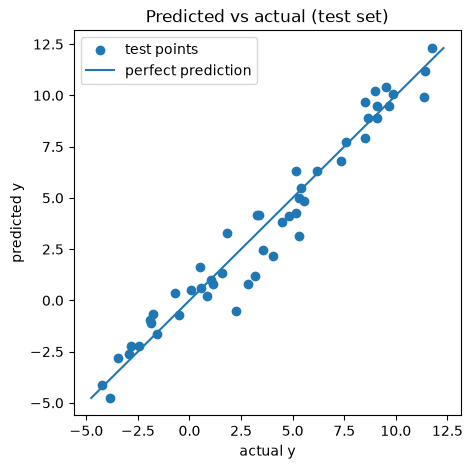

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, test_pred, label='test points')
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
ax.plot(lims, lims, label='perfect prediction')
ax.set_xlabel('actual y')
ax.set_ylabel('predicted y')
ax.set_title('Predicted vs actual (test set)')
ax.legend()
plt.show()

## Interpretation

The recovered intercept and coefficients are close to the true values used to
build the data, and the predicted-vs-actual points hug the diagonal. The train
and test errors are similar, which is what we expect when the model form matches
the data-generating process and there is enough data.

Each coefficient has a direct reading: holding the other feature fixed, a
one-unit increase in a feature changes the prediction by that coefficient.

## Assumptions, limitations, and next steps

OLS rests on several assumptions for its estimates and inference to behave well:

- the relationship between features and target is approximately **linear**,
- the noise terms are roughly independent with constant variance, and
- the features are not strongly collinear (otherwise $X^\top X$ is near-singular
  and the coefficients become unstable).

Limitations follow from these:

- linear regression cannot capture curved or interaction effects unless such
  terms are added by hand,
- it is sensitive to outliers because squared errors penalize large residuals
  heavily, and
- without regularization it can overfit when there are many correlated features.

Natural next steps are **basis expansions** (polynomial or interaction features)
to model non-linearity and **ridge/lasso regularization** to stabilize the
coefficients when features are numerous or collinear.